# Cryptic pocket analysis.

In [25]:
import  numpy as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

mpl.rcParams['font.family'] = ['serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 8.

systems = {'test2_tem1/fpocket_h11':    r"TEM-1(H11)", 
           'test2_tem1/fpocket_omega':  r"TEM-1(ΩLoop)", 
           'test3_bclxl/fpocket':       r"Bcl-x$_L$", 
           'test4_blg/fpocket':         r"βLG", 
           'test5_ndka/fpocket':        r"NDPK-A", 
           'test6_gltp/fpocket':        r"GLTP", }
cm = 1/2.54  # centimeters in inches
colors = ["#F9D9D8", "#EDA3B2", "#7E73AC"]

In [26]:
def get_volume_aflf(which_system: str) -> np.ndarray:
  assert which_system in systems.keys()
  with open(f"./{which_system}/afre/poc_volume.txt", 'r') as f:
    lines = f.readlines()[1:]
    words = [_.split() for _ in lines]
    volms = np.asarray([float(_[1]) for _ in words])
  return volms

def get_volume_refs(which_system: str, get_apo: bool) -> np.ndarray:
  assert which_system in systems.keys()
  apo_pdbs = {'test2_tem1':  r"1JWP", 
              'test3_bclxl': r"3FDL", 
              'test4_blg':   r"1BSQ", 
              'test5_ndka':  r"3L7U", 
              'test6_gltp':  r"1SWX", }
  out = []
  with open(f"./{which_system}/ref/poc_volume.txt", 'r') as f:
    words = [_.split() for _ in f.readlines()[1:]]
    for w in words:
      is_apo = w[0] in apo_pdbs.get(which_system.split('/')[0]).lower()
      if is_apo==get_apo:
        out.append(float(w[1]))
  return out

volms_aflf = {'test2_tem1_h11': get_volume_aflf(which_system='test2_tem1/fpocket_h11'), 
              'test2_tem1_omg': get_volume_aflf(which_system='test2_tem1/fpocket_omega'), 
              'test3_bclxl':    get_volume_aflf(which_system='test3_bclxl/fpocket'), 
              'test4_blg':      get_volume_aflf(which_system='test4_blg/fpocket'), 
              'test5_ndka':     get_volume_aflf(which_system='test5_ndka/fpocket'), 
              'test6_gltp':     get_volume_aflf(which_system='test6_gltp/fpocket'), }

volms_apo  = {'test2_tem1_h11': get_volume_refs(which_system='test2_tem1/fpocket_h11',   get_apo=True), 
              'test2_tem1_omg': get_volume_refs(which_system='test2_tem1/fpocket_omega', get_apo=True), 
              'test3_bclxl':    get_volume_refs(which_system='test3_bclxl/fpocket',      get_apo=True), 
              'test4_blg':      get_volume_refs(which_system='test4_blg/fpocket',        get_apo=True), 
              'test5_ndka':     get_volume_refs(which_system='test5_ndka/fpocket',       get_apo=True), 
              'test6_gltp':     get_volume_refs(which_system='test6_gltp/fpocket',       get_apo=True), }


volms_holo = {'test2_tem1_h11': get_volume_refs(which_system='test2_tem1/fpocket_h11', get_apo=False), 
              'test3_bclxl':    get_volume_refs(which_system='test3_bclxl/fpocket',    get_apo=False), 
              'test4_blg':      get_volume_refs(which_system='test4_blg/fpocket',      get_apo=False), 
              'test5_ndka':     get_volume_refs(which_system='test5_ndka/fpocket',     get_apo=False), 
              'test6_gltp':     get_volume_refs(which_system='test6_gltp/fpocket',     get_apo=False), }

8.0 6.0


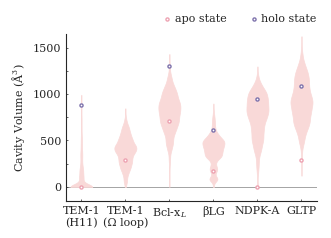

In [27]:
figspec= {'lmargin':11/8*cm, 
          'rmargin':1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  51/8*cm,
          'bmargin': 1  *cm,
          'tmargin': 3/4*cm,
          'vgap':    1/4*cm,
          'vsize':  17/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, ax = plt.subplots(1, 1, figsize=figsize, sharey=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

parts = ax.violinplot(volms_aflf.values(), np.arange(6), widths=0.5, showmeans=False, showextrema=False, showmedians=False, side='both')
for pc in parts['bodies']:
  pc.set_facecolor(colors[0])
  pc.set_edgecolor(colors[0])
  pc.set_linewidth(0.5)
  pc.set_alpha(1)
ax.scatter(np.arange(6),            volms_apo .values(), s=5, c='white', edgecolors=colors[1], label='apo state')
ax.scatter(np.asarray([0,2,3,4,5]), volms_holo.values(), s=5, c='white', edgecolors=colors[2], label='holo state')

ax.axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)
ax.set(ylim=(-150, 1650), 
        yticks=(0, 250, 500, 750, 1000, 1250, 1500),
        yticklabels=(0, '', 500, '', 1000, '', 1500),
        xlim=(-.35, 5.35), 
        xticks=(0,1,2,3,4,5), 
        xticklabels = ('TEM-1\n(H11)', 'TEM-1\n(Ω loop)', r'Bcl-x$_L$', r'βLG', r'NDPK-A', r'GLTP'))
ax.set_ylabel(r'Cavity Volume (Å$^3$)', fontsize=8)

ax.minorticks_off()
ax.spines[['top','right']].set_visible(False)
ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)

fig.legend(loc='upper right', ncol=2, handletextpad=0.3, prop={'size': 8}, handlelength=0.8, frameon=False, bbox_to_anchor=(1, 1))

plt.savefig(f'./zfigures/fig_cryptic_site.jpg', dpi=300)

15.0 22.000000000000004


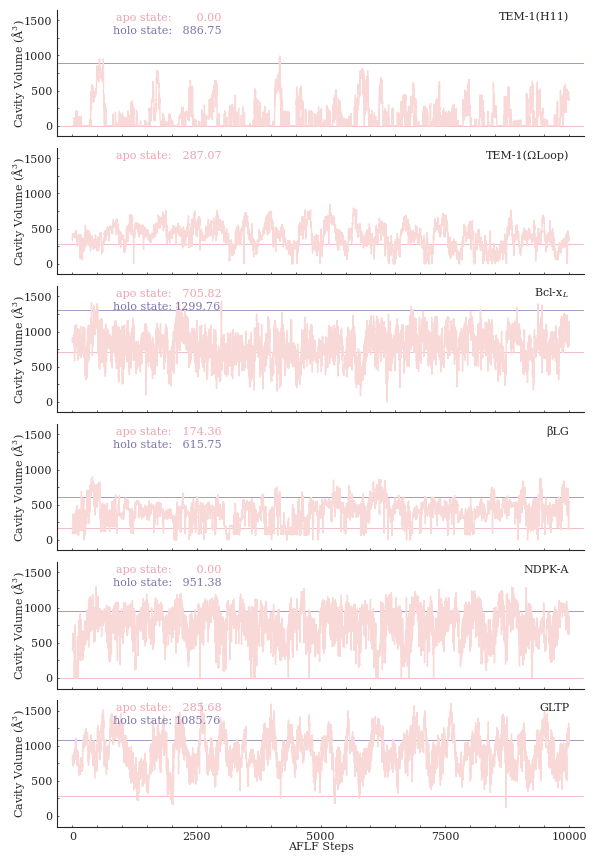

In [28]:
figspec= {'lmargin':11/8*cm, 
          'rmargin':1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  107/8*cm,
          'bmargin': 1  *cm,
          'tmargin': 1/4*cm,
          'vgap':    1/4*cm,
          'vsize':   11/4*cm,}


figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*6 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(6, 1, figsize=figsize, sharex=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

for _ in range(6):
  axes[_].plot(np.arange(1, 10001), list(volms_aflf.values())[_], ls='-', lw=1., c=colors[0])
  # axes[_].axhline(y=0., color=colors[2], ls='-', lw=0.5, zorder=0)
  axes[_].axhline(list(volms_apo.values())[_][0], color=colors[1], ls='-', lw=0.5, zorder=0)
  axes[_].text(2000, 1500, f"apo state:", ha='right', color=colors[1])
  axes[_].text(3000, 1500, f"{list(volms_apo.values())[_][0]:>7.2f}", ha='right', color=colors[1])
  if not _ ==1:
    axes[_].text(2000, 1310, f"holo state:", ha='right', color=colors[2])
    axes[_].text(3000, 1310, f"{list(volms_holo.values())[_-1 if _>1 else 0][0]:>7.2f}", ha='right', color=colors[2])
    axes[_].axhline(list(volms_holo.values())[_-1 if _>1 else 0][0], color=colors[2], ls='-', lw=0.5, zorder=0)
  axes[_].set(ylim=(-150, 1650), 
              yticks=(0, 250, 500, 750, 1000, 1250, 1500),
              yticklabels=(0, '', 500, '', 1000, '', 1500),
              xlim=(-300, 10300), 
              xticks=(   0,  500, 1000, 1500, 2000, 
                      2500, 3000, 3500, 4000, 4500, 
                      5000, 5500, 6000, 6500, 7000, 
                      7500, 8000, 8500, 9000, 9500, 10000), 
              xticklabels=(   0, '', '', '', '', 
                            2500, '', '', '', '', 
                            5000, '', '', '', '', 
                            7500, '', '', '', '', 10000), )
  axes[_].minorticks_off()
  axes[_].spines[['top','right']].set_visible(False)
  axes[_].tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
  axes[_].text(10000, 1500, list(systems.values())[_], ha='right')
  axes[_].set_ylabel(r'Cavity Volume (Å$^3$)', fontsize=8, va='center')

axes[-1].set_xlabel(r'AFLF Steps', fontsize=8, va='center')
plt.savefig(f'./zfigures/fig_cryptic_site_volms.jpg', dpi=300)

In [29]:
def get_rmsds(which_system: str, which_state: str) -> np.ndarray:
  assert which_system in systems.keys()
  with open(f"./{which_system}/afre_rmsd_{which_state}.log", 'r') as f:
    words = [_.split() for _ in f.readlines()[:-1]]
    rmsds = np.asarray([float(_[1]) for _ in words])
  return rmsds

rmsds_opened = {'test2_tem1/fpocket_h11':   get_rmsds(which_system='test2_tem1/fpocket_h11',   which_state='opened'), 
                'test3_bclxl/fpocket':      get_rmsds(which_system='test3_bclxl/fpocket',      which_state='opened'), 
                'test4_blg/fpocket':        get_rmsds(which_system='test4_blg/fpocket',        which_state='opened'), 
                'test5_ndka/fpocket':       get_rmsds(which_system='test5_ndka/fpocket',       which_state='opened'), 
                'test6_gltp/fpocket':       get_rmsds(which_system='test6_gltp/fpocket',       which_state='opened'), }


rmsds_closed = {'test2_tem1/fpocket_h11':   get_rmsds(which_system='test2_tem1/fpocket_h11',   which_state='closed'), 
                'test3_bclxl/fpocket':      get_rmsds(which_system='test3_bclxl/fpocket',      which_state='closed'), 
                'test4_blg/fpocket':        get_rmsds(which_system='test4_blg/fpocket',        which_state='closed'), 
                'test5_ndka/fpocket':       get_rmsds(which_system='test5_ndka/fpocket',       which_state='closed'), 
                'test6_gltp/fpocket':       get_rmsds(which_system='test6_gltp/fpocket',       which_state='closed'), }

systems = {'test2_tem1/fpocket_h11':    r"TEM-1", 
           'test3_bclxl/fpocket':       r"Bcl-x$_L$", 
           'test4_blg/fpocket':         r"βLG", 
           'test5_ndka/fpocket':        r"NDPK-A", 
           'test6_gltp/fpocket':        r"GLTP", }

7.000000000000001 6.0
0.8112047024341599 0.28864434829192953
None 0.4600827092016007
1.9162158896583426 1.636483407905164
0.6161489624691643 0.604634296843261
0.6441157911374259 1.180848216854597


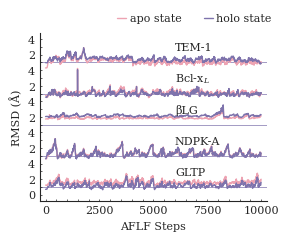

In [30]:
figspec= {'lmargin': 7/8*cm, 
          'rmargin': 3/8*cm,
          'hgap':    1/4*cm,
          'hsize':  23/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 3/4*cm,
          'vgap':    1/4*cm,
          'vsize':  17/4*cm, }

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(1, 1, figsize=figsize, sharex=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))
for _ in range(5):
  print(min(rmsds_opened[list(rmsds_opened.keys())[_]]) if _!=1 else None, min(rmsds_closed[list(rmsds_opened.keys())[_]]))
  axes.plot(np.arange(1, 10001), rmsds_closed[list(rmsds_opened.keys())[_]]+16-_*4, ls='-', lw=1, c=colors[1], label='apo state' if _==0 else '')
  axes.plot(np.arange(1, 10001), rmsds_opened[list(rmsds_opened.keys())[_]]+16-_*4, ls='-', lw=1, c=colors[2], label='holo state'  if _==0 else '')
  axes.axhline(y=1.+_*4, color=colors[2], ls='-', lw=0.5, zorder=0)
  axes.text(6000, 2.5+16-_*4, list(systems.values())[_], ha='left')
axes.set(ylim=(-0.75, 20.75), 
         yticks=     ( 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ),
         yticklabels=( 0, '',  2, '',  4, '',  2, '',  4, '',  2, '',  4, '',  2, '',  4, '',  2, '',  4, ),
          xlim=(-250, 10250), 
            xticks=(   0,  500, 1000, 1500, 2000, 
                    2500, 3000, 3500, 4000, 4500, 
                    5000, 5500, 6000, 6500, 7000, 
                    7500, 8000, 8500, 9000, 9500, 10000), 
            xticklabels=(   0, '', '', '', '', 
                          2500, '', '', '', '', 
                          5000, '', '', '', '', 
                          7500, '', '', '', '', 10000), )
axes.spines[['top', 'right']].set_visible(False)
axes.tick_params(direction='in', width=.5, length=1.5, axis='y', labelsize=8)
axes.tick_params(direction='in', width=.5, length=1.5, axis='x', labelsize=8)
axes.set_ylabel(r'RMSD (Å)', fontsize=8)
axes.set_xlabel(r'AFLF Steps', fontsize=8)
fig.legend(loc='upper right', ncol=2, handletextpad=0.3, prop={'size': 8}, handlelength=0.8, frameon=False, bbox_to_anchor=(1, 1))
plt.savefig(f'./zfigures/fig_cryptic_site_rmsd.jpg', dpi=300)